# 03 — Matriz de correlación (redundancia entre features)

**Objetivo:** detectar **variables redundantes** para podarlas antes de modelar y tener una **vista global única** de las correlaciones (consolida lo disperso en los 6 notebooks de EDA).

**Decisiones de método (acordadas con el equipo):**
- Dataset: versión **oficial de UCI** (123,117 filas, 12 clases, sin `Amazon-Alexa`).
- Se calculan **Spearman y Pearson en paralelo** y se comparan. **Spearman** es el criterio principal: el tráfico de red es muy sesgado y con outliers; capta relaciones monótonas **no lineales** que Pearson no ve.
- Este notebook analiza **redundancia entre features**, NO la relación con el target (eso se difiere al baseline / importancia de RandomForest).

> Salida: tres listas — **conservar**, **botar por redundancia** (`REDUNDANT_COLS_DROP`) y **leaky** (aparte) — que alimentan a `src/data_prep.py`. Explicación didáctica completa en `docs/conceptos_proyecto.md`.

In [2]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

sns.set_theme(style="white")
pd.set_option("display.max_rows", 200)

# Ruta robusta: funciona corriendo desde notebooks/ o desde la raíz del repo
ZIP = Path("../data/rt-iot2022.zip")
if not ZIP.exists():
    ZIP = Path("data/rt-iot2022.zip")

with zipfile.ZipFile(ZIP) as z:
    with z.open("RT_IOT2022") as f:
        df = pd.read_csv(f, index_col=0)

print("shape:", df.shape)
df["Attack_type"].value_counts()

shape: (123117, 84)


Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

## 1. Preparar las variables numéricas

Tomamos solo columnas numéricas y quitamos las **constantes** (varianza cero): con una sola constante, Pearson da `NaN` y ensucia la matriz. Las detectamos automáticamente. También calculamos el **% de ceros** por columna, que usaremos para elegir representantes y para la regla del 1%.

In [3]:
num = df.select_dtypes(include=[np.number]).copy()
if "Attack_type" in num.columns:
    num = num.drop(columns=["Attack_type"])  # por si acaso (es el target)

# columnas 100% constantes -> fuera (en este dataset: bwd_URG_flag_count)
const_cols = [c for c in num.columns if num[c].nunique() <= 1]
print("Columnas constantes (se eliminan para la correlación):", const_cols)
num = num.drop(columns=const_cols)

zeros = (num == 0).mean()  # fracción de ceros por columna
print("Numéricas para correlación:", num.shape[1])

Columnas constantes (se eliminan para la correlación): ['bwd_URG_flag_count']
Numéricas para correlación: 80


## 2. Matrices de correlación: Spearman y Pearson

In [4]:
corr_spear = num.corr(method="spearman")
corr_pear = num.corr(method="pearson")
print("Matriz:", corr_spear.shape)

Matriz: (80, 80)


## 3. Vista global — heatmaps

Triángulo superior enmascarado (la matriz es simétrica). Con ~80 variables el heatmap es denso; sirve para ver **bloques** de redundancia (familias `iat`, `payload`, `header`, `bulk`, `idle`...).

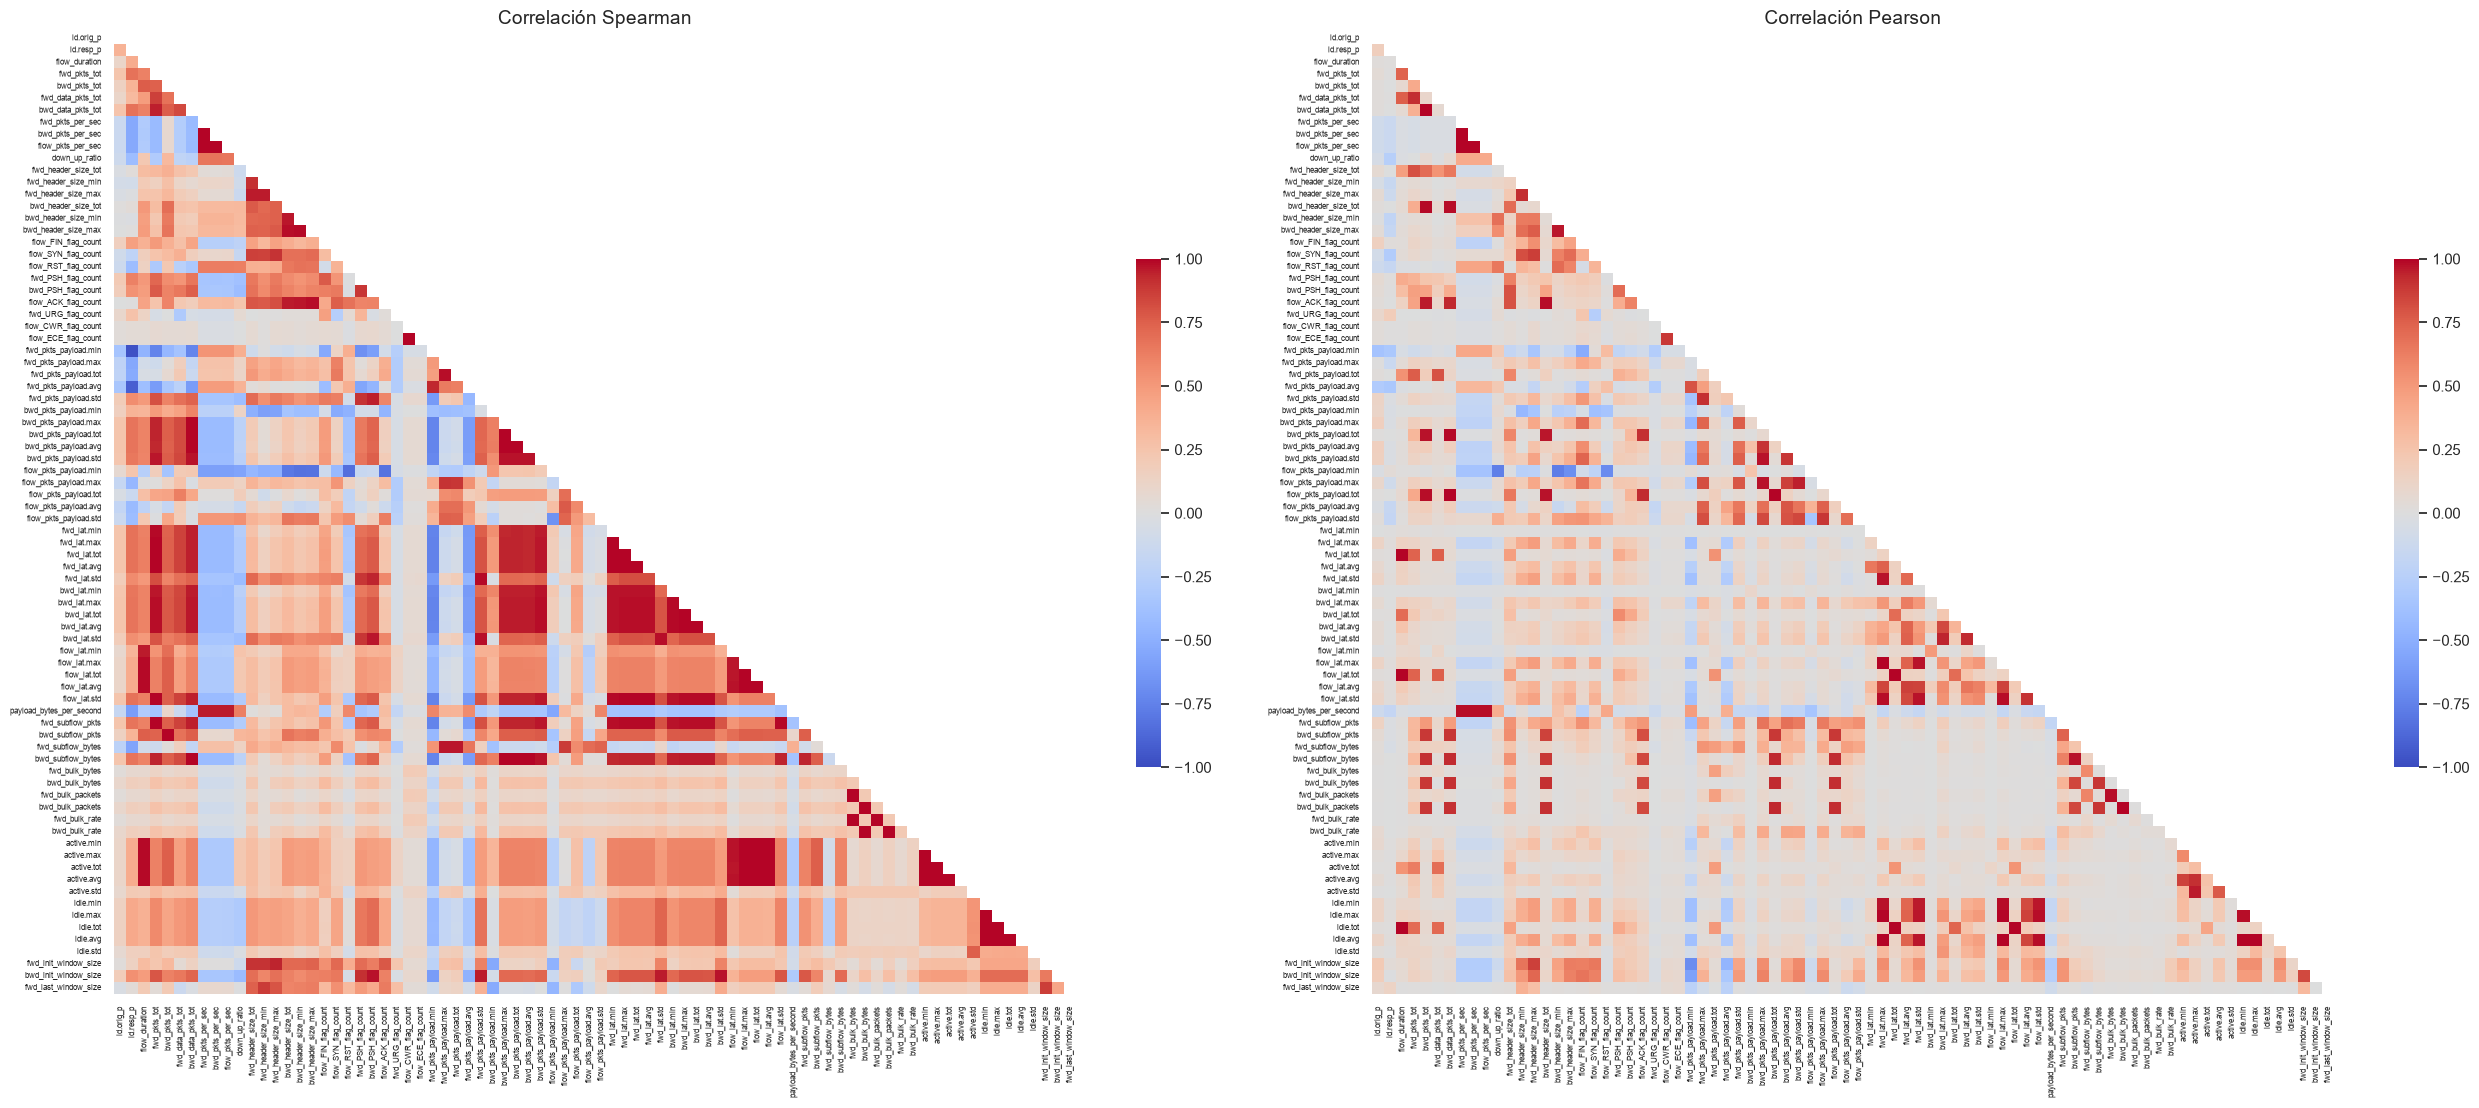

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(26, 11))
mask = np.triu(np.ones_like(corr_spear, dtype=bool))
for ax, corr, name in [(axes[0], corr_spear, "Spearman"), (axes[1], corr_pear, "Pearson")]:
    sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                square=True, cbar_kws={"shrink": 0.5}, ax=ax,
                xticklabels=True, yticklabels=True)
    ax.set_title(f"Correlación {name}", fontsize=14)
    ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

## 4. Clustermap (Spearman) — agrupa visualmente los bloques redundantes

Reordena filas/columnas para que las variables redundantes queden juntas: los cuadros brillantes sobre la diagonal son **familias que miden casi lo mismo**.

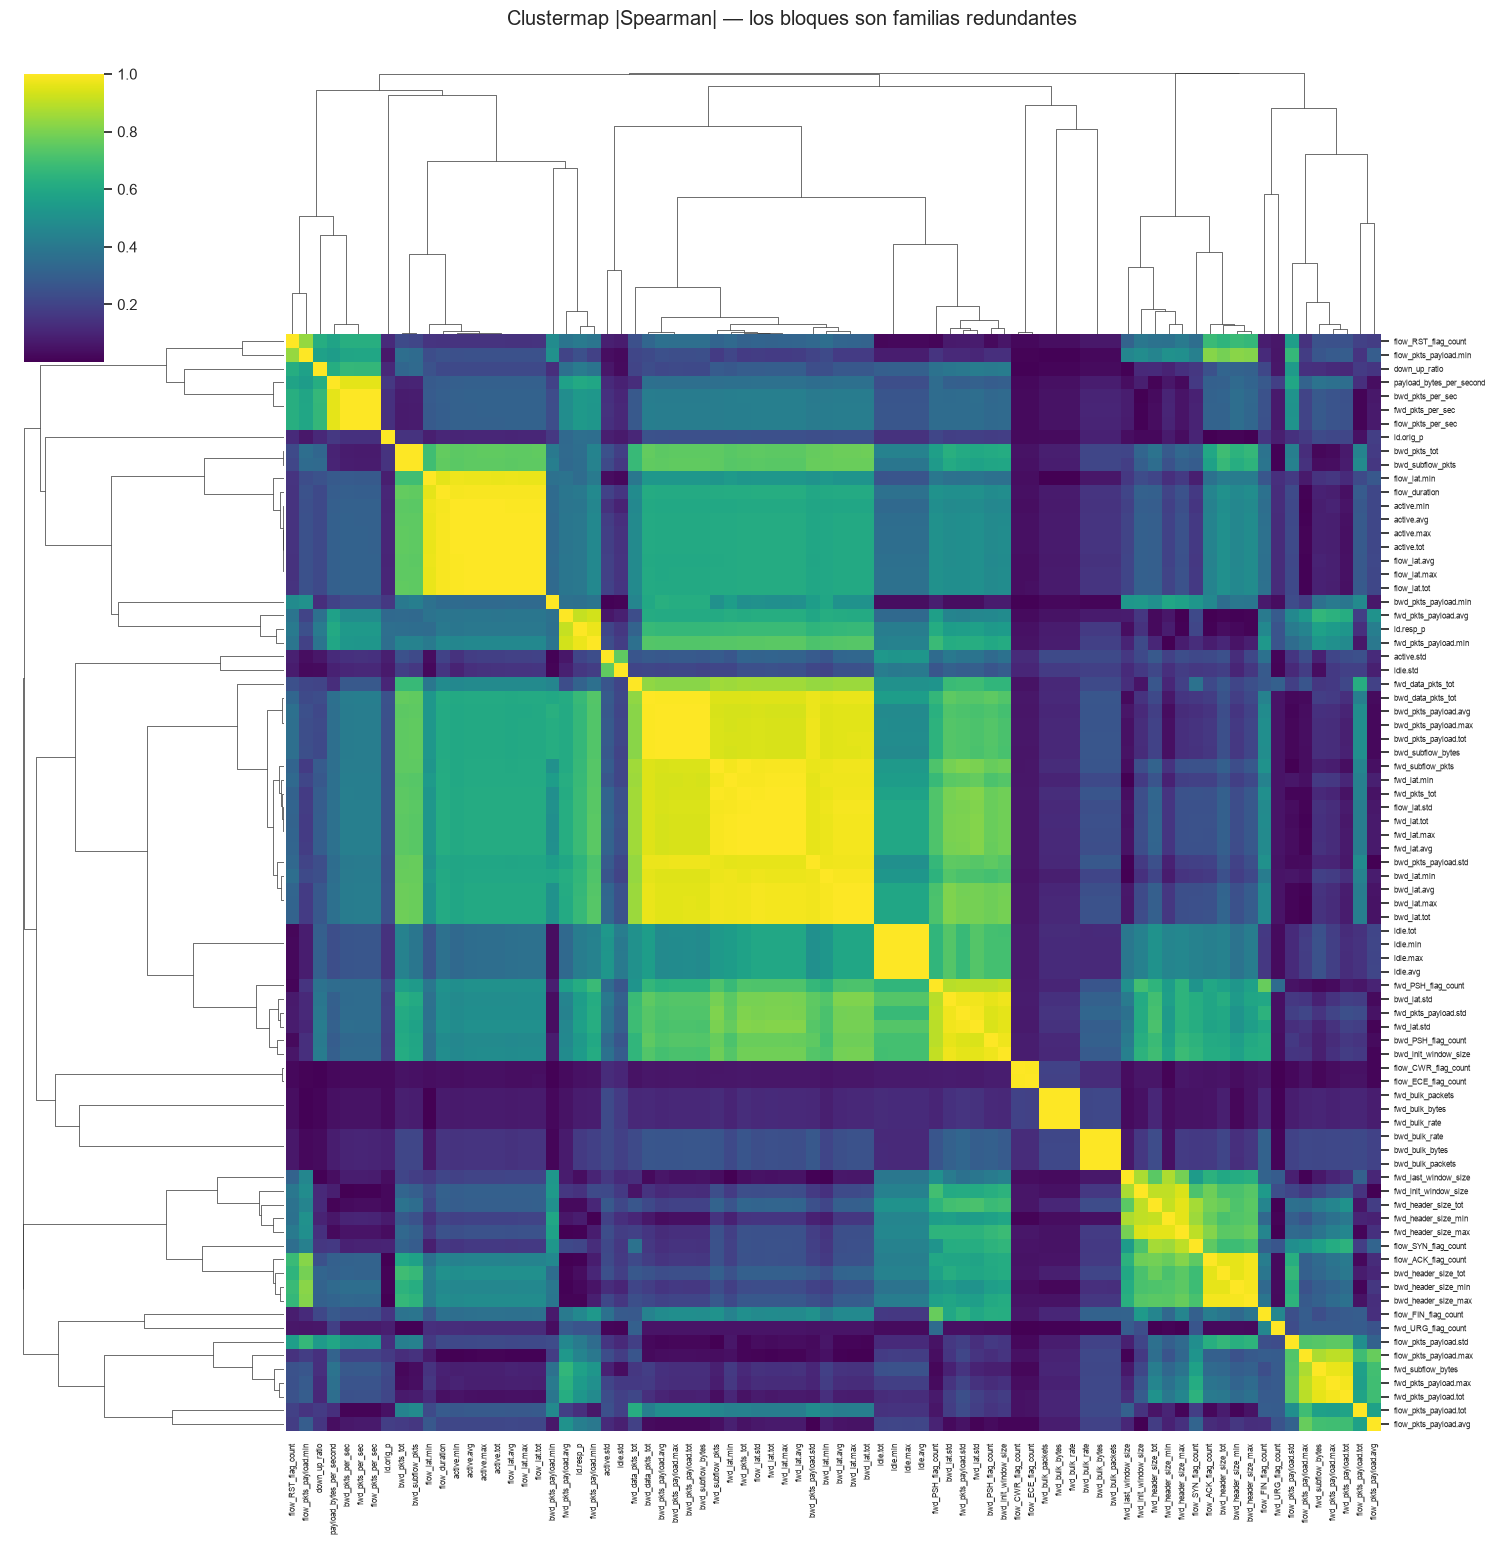

In [6]:
dist = (1 - corr_spear.abs()).to_numpy(copy=True)
np.fill_diagonal(dist, 0.0)
dist = (dist + dist.T) / 2  # simetría exacta para squareform
Z = linkage(squareform(dist, checks=False), method="complete")

g = sns.clustermap(corr_spear.abs(), cmap="viridis", figsize=(16, 16),
                   row_linkage=Z, col_linkage=Z,
                   xticklabels=True, yticklabels=True)
g.ax_heatmap.tick_params(labelsize=6)
g.fig.suptitle("Clustermap |Spearman| — los bloques son familias redundantes", y=1.02)
plt.show()

## 5. Pares con |ρ| > 0.9 — Spearman vs Pearson

Extraemos los pares muy correlacionados por **cada** método y los comparamos. La columna `abs_diff` = |Spearman − Pearson|: cuando es grande, la relación es **monótona pero no lineal** (Pearson la subestima). Es la evidencia de por qué aquí usamos Spearman.

In [7]:
def high_pairs(corr, thr=0.9):
    m = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    s = m.stack()
    return s[s.abs() > thr]

sp_pairs = high_pairs(corr_spear)
pe_pairs = high_pairs(corr_pear)
all_idx = sorted(set(sp_pairs.index) | set(pe_pairs.index))
res = pd.DataFrame([
    {"var_a": a, "var_b": b,
     "spearman": round(corr_spear.loc[a, b], 4),
     "pearson": round(corr_pear.loc[a, b], 4),
     "abs_diff": round(abs(corr_spear.loc[a, b] - corr_pear.loc[a, b]), 4)}
    for a, b in all_idx
]).sort_values("spearman", key=lambda c: c.abs(), ascending=False).reset_index(drop=True)

print(f"Pares |ρ|>0.9 (unión de ambos métodos): {len(res)}")
print(f"  solo Spearman: {len(set(sp_pairs.index) - set(pe_pairs.index))}")
print(f"  solo Pearson : {len(set(pe_pairs.index) - set(sp_pairs.index))}")
print(f"  no-lineales (|diff|>0.2): {(res['abs_diff'] > 0.2).sum()}")
res.head(40)

Pares |ρ|>0.9 (unión de ambos métodos): 277
  solo Spearman: 202
  solo Pearson : 54
  no-lineales (|diff|>0.2): 239


,var_a,var_b,spearman,pearson,abs_diff
0,idle.min,idle.max,1.0000,0.9780,0.0220
1,fwd_pkts_per_sec,flow_pkts_per_sec,1.0000,1.0000,0.0000
2,fwd_bulk_bytes,fwd_bulk_rate,1.0000,0.0548,0.9452
3,active.max,active.tot,1.0000,0.2916,0.7084
4,fwd_bulk_packets,fwd_bulk_rate,1.0000,0.0633,0.9367
5,flow_iat.max,flow_iat.tot,1.0000,0.1362,0.8638
6,fwd_bulk_bytes,fwd_bulk_packets,1.0000,0.9766,0.0234
7,bwd_bulk_bytes,bwd_bulk_rate,1.0000,0.0278,0.9721
8,bwd_bulk_packets,bwd_bulk_rate,1.0000,0.0342,0.9658
9,idle.max,idle.avg,1.0000,0.9951,0.0049


## 6. Agrupar la redundancia (clustering jerárquico)

Decidir par-a-par es inmanejable. Agrupamos en **familias redundantes** con clustering jerárquico sobre `1 − |Spearman|` y **complete linkage** (criterio estricto: **todos** los pares dentro de un grupo cumplen |ρ|>0.9). De cada grupo se conserva un representante.

**Regla del representante (acordada):** `no-leaky → más denso (menos ceros) → más interpretable`. También reportamos el `min|ρ|` de cada grupo: grupos "sueltos" (<0.95) son candidatos a conservar un **2º representante** de faceta distinta.

In [8]:
LEAKY = {"id.orig_p", "id.resp_p", "service", "proto"}  # se manejan con el toggle include_leaky

labels = fcluster(Z, t=0.1, criterion="distance")  # corte en |ρ| = 0.9
groups = {}
for col, lab in zip(num.columns, labels):
    groups.setdefault(lab, []).append(col)
redundant = {k: v for k, v in groups.items() if len(v) > 1}
singletons = [v[0] for k, v in groups.items() if len(v) == 1]

def interp_pen(name):
    for suf, p in [(".std", 3), (".min", 2), (".max", 2), (".avg", 1), (".tot", 0)]:
        if name.endswith(suf):
            return p
    return -1  # nombre base sin sufijo estadístico = más interpretable

def pick_rep(members):
    return sorted(members, key=lambda c: (c in LEAKY, round(zeros[c], 3), interp_pen(c), c))[0]

print("=== GRUPOS REDUNDANTES (regla: no-leaky -> denso -> interpretable) ===\n")
ordered = sorted(redundant.items(), key=lambda kv: -len(kv[1]))
for i, (k, v) in enumerate(ordered, 1):
    sub = corr_spear.loc[v, v].abs().values
    min_rho = sub[~np.eye(len(v), dtype=bool)].min()
    rep = pick_rep(v)
    loose = "  <-- SUELTO (evaluar 2o rep)" if min_rho < 0.95 else ""
    print(f"GRUPO {i} ({len(v)} vars)  min|rho|={min_rho:.3f}  rep_sugerido={rep}{loose}")
    for c in v:
        print(f"    {'KEEP ' if c == rep else 'drop '}{c}  (ceros={zeros[c]*100:.0f}%)")
    print()
print("=== SOLITARIAS (sin redundancia >0.9, se conservan todas salvo leaky) ===")
print(f"{len(singletons)}: {', '.join(singletons)}")

=== GRUPOS REDUNDANTES (regla: no-leaky -> denso -> interpretable) ===

GRUPO 1 (17 vars)  min|rho|=0.934  rep_sugerido=fwd_pkts_tot  <-- SUELTO (evaluar 2o rep)
    KEEP fwd_pkts_tot  (ceros=0%)
    drop bwd_data_pkts_tot  (ceros=86%)
    drop bwd_pkts_payload.max  (ceros=86%)
    drop bwd_pkts_payload.tot  (ceros=86%)
    drop bwd_pkts_payload.avg  (ceros=86%)
    drop bwd_pkts_payload.std  (ceros=86%)
    drop fwd_iat.min  (ceros=86%)
    drop fwd_iat.max  (ceros=86%)
    drop fwd_iat.tot  (ceros=86%)
    drop fwd_iat.avg  (ceros=86%)
    drop bwd_iat.min  (ceros=86%)
    drop bwd_iat.max  (ceros=86%)
    drop bwd_iat.tot  (ceros=86%)
    drop bwd_iat.avg  (ceros=86%)
    drop flow_iat.std  (ceros=86%)
    drop fwd_subflow_pkts  (ceros=0%)
    drop bwd_subflow_bytes  (ceros=86%)

GRUPO 2 (9 vars)  min|rho|=0.960  rep_sugerido=flow_duration
    KEEP flow_duration  (ceros=13%)
    drop flow_iat.min  (ceros=13%)
    drop flow_iat.max  (ceros=13%)
    drop flow_iat.tot  (ceros=13%)
    

## 7. Regla del 1% — familias casi-constantes

Varias familias son ~99% ceros. **La regla del 1%:** si ese 1% no-cero se concentra en una clase, es **señal rara valiosa** → no botar por reflejo. Verificamos dónde caen los no-cero (normal vs ataque).

In [9]:
NORMAL_CLASSES = {"MQTT_Publish", "Thing_Speak", "Wipro_bulb"}
y_bin = (~df["Attack_type"].isin(NORMAL_CLASSES)).astype(int)  # 1=ataque, 0=normal

fams = {
    "idle.*": ["idle.min", "idle.max", "idle.avg", "idle.tot"],
    "fwd_bulk.*": ["fwd_bulk_bytes", "fwd_bulk_packets", "fwd_bulk_rate"],
    "bwd_bulk.*": ["bwd_bulk_bytes", "bwd_bulk_packets", "bwd_bulk_rate"],
    "flow_CWR/ECE": ["flow_CWR_flag_count", "flow_ECE_flag_count"],
}
for fam, cols in fams.items():
    cols = [c for c in cols if c in df.columns]
    nz = (df[cols] != 0).any(axis=1)
    n = int(nz.sum())
    pct_atk = y_bin[nz].mean() * 100 if n else 0
    print(f"{fam:14s} no-cero={n:6d} ({n/len(df)*100:5.2f}%)  -> {pct_atk:5.1f}% ataque / {100-pct_atk:5.1f}% normal")
    if n:
        print("               top:", dict(df.loc[nz, "Attack_type"].value_counts().head(3)))
print("\nDecision: CONSERVAR idle (normal), fwd_bulk (ARP), flow_CWR (normal); BOTAR bwd_bulk (mezclado).")

idle.*         no-cero=  5697 ( 4.63%)  ->  27.8% ataque /  72.2% normal
               top: {'MQTT_Publish': np.int64(3939), 'ARP_poisioning': np.int64(1295), 'DDOS_Slowloris': np.int64(282)}
fwd_bulk.*     no-cero=   246 ( 0.20%)  ->  80.9% ataque /  19.1% normal
               top: {'ARP_poisioning': np.int64(196), 'Thing_Speak': np.int64(46), 'NMAP_UDP_SCAN': np.int64(2)}
bwd_bulk.*     no-cero=  1107 ( 0.90%)  ->  45.9% ataque /  54.1% normal
               top: {'Thing_Speak': np.int64(594), 'ARP_poisioning': np.int64(508), 'MQTT_Publish': np.int64(3)}
flow_CWR/ECE   no-cero=    72 ( 0.06%)  ->   0.0% ataque / 100.0% normal
               top: {'Thing_Speak': np.int64(51), 'Wipro_bulb': np.int64(21)}

Decision: CONSERVAR idle (normal), fwd_bulk (ARP), flow_CWR (normal); BOTAR bwd_bulk (mezclado).


## 8. Decisiones acordadas por el equipo (overrides)

El algoritmo **propone**; el equipo **decide**. Ajustes manuales acordados sobre la sugerencia automática (detalle del razonamiento en `docs/conceptos_proyecto.md` §10–11):

- **G6 → conservar ambas**: `bwd_header_size_max` **+** `flow_ACK_flag_count` (ACK es interpretable para un IDS).
- **G3 → representante** = `bwd_init_window_size` (más interpretable que `fwd_iat.std`); además se conserva `fwd_iat.std` como 2º rep (faceta distinta).
- **2º representante** (faceta distinta) en los grupos sueltos: G1 (`bwd_pkts_payload.avg`), G5 (`fwd_init_window_size`).
- **G8** se queda con 1 (su único candidato `fwd_pkts_payload.min` es el mismo facet payload).
- **Leaky** (`id.orig_p`, `id.resp_p`, `service`, `proto`): **fuera** de la poda; van por el toggle `include_leaky` de `build_preprocessor`.

In [10]:
# Fuente de verdad para src/data_prep.py (lista ACORDADA, no la cruda del algoritmo).
REDUNDANT_COLS_DROP = [
    # G1 (reps = fwd_pkts_tot + bwd_pkts_payload.avg)
    "bwd_data_pkts_tot", "bwd_pkts_payload.max", "bwd_pkts_payload.tot", "bwd_pkts_payload.std",
    "fwd_iat.min", "fwd_iat.max", "fwd_iat.tot", "fwd_iat.avg",
    "bwd_iat.min", "bwd_iat.max", "bwd_iat.tot", "bwd_iat.avg",
    "flow_iat.std", "fwd_subflow_pkts", "bwd_subflow_bytes",
    # G2 (rep = flow_duration)
    "flow_iat.min", "flow_iat.max", "flow_iat.tot", "flow_iat.avg",
    "active.min", "active.max", "active.tot", "active.avg",
    # G3 (reps = bwd_init_window_size + fwd_iat.std)
    "bwd_PSH_flag_count", "fwd_pkts_payload.std", "bwd_iat.std",
    # G4 (rep = flow_pkts_per_sec)
    "fwd_pkts_per_sec", "bwd_pkts_per_sec", "payload_bytes_per_second",
    # G5 (reps = fwd_header_size_max + fwd_init_window_size)
    "fwd_header_size_tot", "fwd_header_size_min",
    # G6 (se conservan 2: bwd_header_size_max + flow_ACK_flag_count)
    "bwd_header_size_tot", "bwd_header_size_min",
    # G7 idle (rep = idle.tot)
    "idle.min", "idle.max", "idle.avg",
    # G8 (rep = fwd_pkts_payload.avg)
    "fwd_pkts_payload.min",
    # G9 (rep = fwd_subflow_bytes)
    "fwd_pkts_payload.max", "fwd_pkts_payload.tot",
    # G10 fwd_bulk (rep = fwd_bulk_bytes)
    "fwd_bulk_packets", "fwd_bulk_rate",
    # G11 bwd_bulk: FAMILIA ENTERA (mezclada, sin señal clara)
    "bwd_bulk_bytes", "bwd_bulk_packets", "bwd_bulk_rate",
    # G12 (rep = bwd_pkts_tot)
    "bwd_subflow_pkts",
    # G13 (rep = flow_CWR_flag_count)
    "flow_ECE_flag_count",
]
faltan = [c for c in REDUNDANT_COLS_DROP if c not in df.columns]
assert not faltan, f"columnas inexistentes: {faltan}"
print(f"REDUNDANT_COLS_DROP: {len(REDUNDANT_COLS_DROP)} columnas (OK, todas existen)")

REDUNDANT_COLS_DROP: 46 columnas (OK, todas existen)


## 9. Resumen final — tres listas para `src/data_prep.py`

In [11]:
REPRESENTANTES = [
    "fwd_pkts_tot", "bwd_pkts_payload.avg",        # G1 (2)
    "flow_duration",                               # G2
    "bwd_init_window_size", "fwd_iat.std",          # G3 (2)
    "flow_pkts_per_sec",                            # G4
    "fwd_header_size_max", "fwd_init_window_size",  # G5 (2)
    "bwd_header_size_max", "flow_ACK_flag_count",   # G6 (2)
    "idle.tot",                                     # G7
    "fwd_pkts_payload.avg",                         # G8
    "fwd_subflow_bytes",                            # G9
    "fwd_bulk_bytes",                              # G10
    "bwd_pkts_tot",                                # G12
    "flow_CWR_flag_count",                          # G13
]
LEAKY_COLS = ["id.orig_p", "id.resp_p", "service", "proto"]
CONSTANT_DROP = const_cols  # detectadas arriba (bwd_URG_flag_count)

sobreviven = sorted(set(REPRESENTANTES) | (set(singletons) - LEAKY))
print(f"Constante a botar (siempre):  {CONSTANT_DROP}")
print(f"Redundancia a botar:          {len(REDUNDANT_COLS_DROP)} columnas")
print(f"Leaky (toggle, NO se podan):  {LEAKY_COLS}")
print(f"Categóricas:                  ['proto', 'service'] (one-hot si include_leaky=True)")
print(f"\nFeatures numéricas que sobreviven: {len(sobreviven)}")
for c in sobreviven:
    print("   -", c)

Constante a botar (siempre):  ['bwd_URG_flag_count']
Redundancia a botar:          46 columnas
Leaky (toggle, NO se podan):  ['id.orig_p', 'id.resp_p', 'service', 'proto']
Categóricas:                  ['proto', 'service'] (one-hot si include_leaky=True)

Features numéricas que sobreviven: 32
   - active.std
   - bwd_header_size_max
   - bwd_init_window_size
   - bwd_pkts_payload.avg
   - bwd_pkts_payload.min
   - bwd_pkts_tot
   - down_up_ratio
   - flow_ACK_flag_count
   - flow_CWR_flag_count
   - flow_FIN_flag_count
   - flow_RST_flag_count
   - flow_SYN_flag_count
   - flow_duration
   - flow_pkts_payload.avg
   - flow_pkts_payload.max
   - flow_pkts_payload.min
   - flow_pkts_payload.std
   - flow_pkts_payload.tot
   - flow_pkts_per_sec
   - fwd_PSH_flag_count
   - fwd_URG_flag_count
   - fwd_bulk_bytes
   - fwd_data_pkts_tot
   - fwd_header_size_max
   - fwd_iat.std
   - fwd_init_window_size
   - fwd_last_window_size
   - fwd_pkts_payload.avg
   - fwd_pkts_tot
   - fwd_subflow_by

## 10. Conclusiones de la sección

1. **Redundancia fuerte:** ~80 numéricas colapsan a ~31 conservando 1–2 representantes por grupo. Las familias `iat`, `active/idle`, `payload`, `header`, `bulk` y `pkts_per_sec` son internamente casi idénticas.
2. **Spearman ≫ Pearson** en varios pares (`abs_diff` grande): relaciones monótonas **no lineales** → confiar en Spearman para esta decisión.
3. **⚠️ Caveat — correlación por *ceros compartidos*:** muchas de estas variables son 90%+ ceros **en las mismas filas** (flujos sin tráfico de respuesta / sin IAT). Spearman las ve "casi idénticas" porque comparten el patrón de ceros, no porque su parte no-cero sea igual. Por eso aplicamos la **regla del 1%** (§7) antes de botar familias casi-constantes.
4. **`id.resp_p` (puerto destino) cae en un grupo redundante** y además es **leaky** (correlaciona >0.9 con `fwd_pkts_payload.avg`: el puerto "predice" el payload). Se maneja por el toggle, no por la poda.
5. **El algoritmo prioriza unicidad estadística, no interpretabilidad.** Por eso el equipo aplicó overrides (§8): conservar `flow_ACK_flag_count`, `bwd_init_window_size`, `flow_duration`, etc.

**Próximo paso:** trasladar `REDUNDANT_COLS_DROP`, `LEAKY_COLS` y `CONSTANT_DROP` a `src/data_prep.py` (constantes documentadas) para una limpieza reproducible.

## 11. Validación del clustering y del punto de corte

Esta sección evalúa la calidad de las familias generadas por el clustering jerárquico y analiza el comportamiento del punto de corte adoptado por el equipo.

La validación se realiza sobre el mismo clustering generado en las secciones
anteriores, utilizando los objetos `corr_spear`, `dist`, `Z` y `labels`.

Se emplean cuatro índices de validación interna:

- Silhouette Score.
- Davies-Bouldin Index.
- Calinski-Harabasz Index.
- Dunn Index.

Estos índices se utilizan como evidencia complementaria para evaluar la
separación y cohesión de los grupos. Además, analizamos si la estructura obtenida con `|ρ| = 0.9` resulta favorable.

In [13]:
# Silhouette Score
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    dist,
    labels,
    metric="precomputed"
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.6633


In [14]:
# Indice de Davies-Bouldin
from sklearn.metrics import davies_bouldin_score

X_cluster = dist.copy()

db = davies_bouldin_score(
    X_cluster,
    labels
)

print(f"Davies-Bouldin Index: {db:.4f}")

Davies-Bouldin Index: 0.2171


In [15]:
# Indice de Calinski-Harabasz
from sklearn.metrics import calinski_harabasz_score

ch = calinski_harabasz_score(
    X_cluster,
    labels
)

print(f"Calinski-Harabasz Index: {ch:.4f}")

Calinski-Harabasz Index: 225.6875


In [16]:
# Indice de Dunn
def dunn_index(distance_matrix, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    # Máxima distancia dentro de cada grupo
    max_intra = 0.0

    for label in unique_labels:
        idx = np.where(labels == label)[0]

        if len(idx) > 1:
            intra = distance_matrix[np.ix_(idx, idx)]
            max_intra = max(max_intra, np.max(intra))

    # Mínima distancia entre grupos
    min_inter = np.inf

    for i, label_i in enumerate(unique_labels):
        idx_i = np.where(labels == label_i)[0]

        for label_j in unique_labels[i + 1:]:
            idx_j = np.where(labels == label_j)[0]

            inter = distance_matrix[np.ix_(idx_i, idx_j)]
            min_inter = min(min_inter, np.min(inter))

    return min_inter / max_intra


dunn = dunn_index(dist, labels)

print(f"Dunn Index: {dunn:.4f}")

Dunn Index: 0.9527


In [17]:
#Resumimos
indices_validacion = pd.DataFrame({
    "Indice": [
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz",
        "Dunn"
    ],
    "Valor": [
        silhouette,
        db,
        ch,
        dunn
    ],
    "Criterio": [
        "Mayor es mejor",
        "Menor es mejor",
        "Mayor es mejor",
        "Mayor es mejor"
    ]
})

indices_validacion

,Indice,Valor,Criterio
0,Silhouette,0.663332,Mayor es mejor
1,Davies-Bouldin,0.217108,Menor es mejor
2,Calinski-Harabasz,225.687463,Mayor es mejor
3,Dunn,0.952666,Mayor es mejor


In [20]:
# Evaluación del punto de corte |p| = 0.9
cutoffs = [0.80, 0.85, 0.90, 0.95, 0.99]

resultados_cutoff = []

for rho_cut in cutoffs:

    distance_cut = 1 - rho_cut

    labels_cut = fcluster(
        Z,
        t=distance_cut,
        criterion="distance"
    )

    n_groups = len(np.unique(labels_cut))

    # Silhouette requiere al menos 2 grupos
    if n_groups > 1:
        sil = silhouette_score(
            dist,
            labels_cut,
            metric="precomputed"
        )

        db_cut = davies_bouldin_score(
            dist,
            labels_cut
        )

        ch_cut = calinski_harabasz_score(
            dist,
            labels_cut
        )

        dunn_cut = dunn_index(
            dist,
            labels_cut
        )

    else:
        sil = np.nan
        db_cut = np.nan
        ch_cut = np.nan
        dunn_cut = np.nan

    resultados_cutoff.append({
        "corte_|p|": rho_cut,
        "distancia": distance_cut,
        "num_grupos": n_groups,
        "silhouette": sil,
        "davies_bouldin": db_cut,
        "calinski_harabasz": ch_cut,
        "dunn": dunn_cut
    })

resultados_cutoff = pd.DataFrame(resultados_cutoff)

resultados_cutoff

,corte_|p|,distancia,num_grupos,silhouette,davies_bouldin,calinski_harabasz,dunn
0,0.80,0.20,26,0.712605,0.257594,156.421913,0.560704
1,0.85,0.15,28,0.688419,0.223124,204.134399,0.817303
2,0.90,0.10,30,0.663332,0.217108,225.687463,0.952666
3,0.95,0.05,35,0.604039,0.260190,334.829619,0.634254
4,0.99,0.01,52,0.425996,0.104180,1739.141390,0.744881


## 12. Conclusión 

El punto de corte \(|ρ|=0.90\) presenta un comportamiento favorable en los índices de validación interna. Obtiene:

- un Silhouette de 0.663332
- un Davies-Bouldin de 0.217108
- un Calinski-Harabasz de 225.687463
- un índice de Dunn de 0.952666

Aunque algunos índices alcanzan mejores valores en un corte más estricto como 0.99, este producen un número considerablemente mayor de grupos (52), reduciendo la capacidad de consolidar variables redundantes. Por tanto, \(|ρ|=0.90\) comprende un balance razonable entre cohesión/separación de los grupos y una poda efectiva de redundancia.